# OCR: CNN

We'll train on easily accessible [NFL datasets](https://www.kaggle.com/datasets/frlemarchand/nfl-player-numbers?resource=download), and then transfer to NBA (assuming jerseys are similar in shape and color). 

We can just build a lightweight CNN outputting a smoothed label distribution from [0, 00, 1-99] $\in \mathbb{R}^{101}$. The NFL data doesn't have '00', so we'll need to implement a pre-processing OCR step to gracefully handle this edge case, preventing silent failures. 

1. Fast OCR (i.e. Tesseract) to see if '00' is in the image. If so, we're done.
2. If not, run through the CNN to get a smoothed label distribution for numbers 0 through 99.

## Installs + Imports

In [152]:
import mlflow
import os
import polars as pl
import numpy as np 
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
from torchsummary import summary

from contextlib import ExitStack
from sklearn.model_selection import train_test_split

from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

jersey_path = "../data/.cache/nfl_jersey_numbers"
NUM_CLASSES = 100

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("jersey_ocr")

<Experiment: artifact_location='/Users/rjunw/Desktop/dev/nba2nba/notebooks/mlruns/2', creation_time=1764964024504, experiment_id='2', last_update_time=1764964024504, lifecycle_stage='active', name='jersey_ocr', tags={}>

In [106]:
print(f"CUDA: {torch.cuda.is_available()}")

CUDA: False


## Helpers

In [ ]:
def calculate_cmat(y_true, y_pred, n_classes):
    """
    Calculate confusion matrix. 

    - Diags are TP counts
    - cmat.sum(axis = 1) would give TP + FN since it counts all the y_true = class
    - cmat.sum(axis = 0) would give TP + FP since it counts all the y_pred = class
    """ 
    cm = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            cm[i, j] = np.sum((y_true == i) & (y_pred == j))
    return cm
a = calculate_cmat(np.array([1, 2, 3, 2, 1, 1, 2, 0]), np.array([1, 2, 3, 1, 1, 3, 3, 0]), 5)
a

array([[1., 0., 0., 0., 0.],
       [0., 2., 0., 1., 0.],
       [0., 1., 1., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0.]])

In [ ]:
a.sum(axis=0)

array([1., 3., 1., 3., 0.])

In [132]:
def step(model, batch, criterion, optimizer, device, step_type = "train"):
    inputs, labels = batch
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    if step_type == "train":
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    preds = torch.argmax(outputs, dim = 1)
    
    confusion_mat = calculate_cmat(preds, labels, NUM_CLASSES)
    
    return loss.item(), confusion_mat

def epoch_step(model, dataloader, criterion, optimizer, device, step_type = "train"):    
    if step_type == "train":
        model.train()
    else:
        model.eval()

    # set context manager for gradient tracking if needed
    with ExitStack() as stack:
        if step_type == "train":
            stack.enter_context(torch.enable_grad())
        else:
            stack.enter_context(torch.no_grad())

        running_loss = 0
        confusion_mat = np.zeros((NUM_CLASSES, NUM_CLASSES))
        for batch in dataloader:
            loss, confusion_mat = step(model, batch, criterion, optimizer, device, step_type)
            running_loss += loss
            confusion_mat += confusion_mat
        

    return running_loss / len(dataloader), confusion_mat
    

## Dataset

In [169]:
class JerseyDataset(Dataset):
    def __init__(self, image_dir, df, transform=None):
        self.image_dir = image_dir
        self.df = df
        self.df = (
            self.df
            .select("filename", "label")
            .unique() # there seem to be some duplicates
        )

        self.transform = transform
        self.images = df.select("filename").to_series()
        self.labels = df.select("label").to_series()
    
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # read in the image
        image_path = os.path.join(self.image_dir, self.images[idx])
        image = decode_image(image_path) 
        label = self.labels[idx]
        label = torch.Tensor([label])

        # apply transforms if necessary
        if self.transform is not None:
            image = self.transform(image)
        return image, label 

In [ ]:
jersey_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = pl.read_csv(os.path.join(jersey_path, "train_player_numbers.csv")),
)
print(len(jersey_ds))

43879


## Model Definition

In [108]:
class OCRNet(nn.Module):
    def __init__(self, kernel, num_filters, num_in_channels, num_classes, width, height):
        super().__init__()

        # keep output featuremap size = input featuremap size
        # recall, Wo = (Wi - k + 2p)/s + 1
        #   => s = 1, Wo = Wi - k + 2p + 1
        #   => 0 = -k + 2p + 1 (because we want Wo = Wi)
        #   => p = (k-1)/2
        padding = kernel//2 # this is the same as (kernel-1)/2 for odd kernel

        # (W/2, H/2, num_filters)
        self.block1 = nn.Sequential(
            nn.Conv2d(num_in_channels, num_filters, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters),
            nn.ReLU()
        )

        # (W/4, H/4, num_filters*2)
        self.block2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU()
        )

        # (W/8, H/8, num_filters*4)
        self.block3 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*4, kernel_size=kernel, padding=padding),
            nn.MaxPool2d(kernel_size = 2),
            nn.BatchNorm2d(num_filters*4),
            nn.ReLU()
        )

        # projection layer
        self.project = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_filters*4 * width // 8 * height // 8, 512),
            nn.ReLU()
        )

        self.classifier = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # feature extraction
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # flatten and project
        x = self.project(x)

        # classifier head
        x = self.classifier(x)
        x = F.log_softmax(x, dim=1) # log softmax for stable training
        return x

In [109]:
model_kwargs = {
    "kernel": 3,
    "num_filters": 64,
    "num_in_channels": 3,
    "num_classes": 100,
    "width": 64,
    "height": 64,
}
model = OCRNet(**model_kwargs)
summary(model, (3, 64, 64), verbose=0) # verbose prevents duplicate print

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 32, 32]          --
|    └─Conv2d: 2-1                       [-1, 64, 64, 64]          1,792
|    └─MaxPool2d: 2-2                    [-1, 64, 32, 32]          --
|    └─BatchNorm2d: 2-3                  [-1, 64, 32, 32]          128
|    └─ReLU: 2-4                         [-1, 64, 32, 32]          --
├─Sequential: 1-2                        [-1, 128, 16, 16]         --
|    └─Conv2d: 2-5                       [-1, 128, 32, 32]         73,856
|    └─MaxPool2d: 2-6                    [-1, 128, 16, 16]         --
|    └─BatchNorm2d: 2-7                  [-1, 128, 16, 16]         256
|    └─ReLU: 2-8                         [-1, 128, 16, 16]         --
├─Sequential: 1-3                        [-1, 256, 8, 8]           --
|    └─Conv2d: 2-9                       [-1, 256, 16, 16]         295,168
|    └─MaxPool2d: 2-10                   [-1, 256, 8, 8]           --
|

## Training

### Dataloaders

In [ ]:
# define augmentations we want to run
train_transform = v2.Compose([
    v2.ToDtype(torch.float32),
    v2.Resize((64, 64)),
    v2.RandomRotation(20), # light rotation to avoid digits being flipped
    v2.RandomPerspective(distortion_scale=0.2),
    v2.ElasticTransform(alpha=50),
    v2.ColorJitter(brightness = 0.2, hue = 0.2),
    v2.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # normalize isn't working, need to bugfix
])

eval_transform = v2.Compose([
    v2.ToDtype(torch.float32),
    v2.Resize((64, 64)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 1 - TRAIN_SIZE - VAL_SIZE

jersey_df = pl.read_csv(os.path.join(jersey_path, "train_player_numbers.csv"))
jersey_df = (
    jersey_df
    .select("filename", "label")
    .unique()
)

train_idx, test_idx = train_test_split(list(range(len(jersey_df))), train_size=TRAIN_SIZE, test_size=TEST_SIZE, random_state=SEED)
val_idx, test_idx = train_test_split(test_idx, train_size=VAL_SIZE, test_size=TEST_SIZE, random_state=SEED)

train_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[train_idx],
    transform = train_transform
)

val_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[val_idx],
    transform = eval_transform
)

test_ds = JerseyDataset(
    image_dir = os.path.join(jersey_path, "train_player_numbers/"),
    df = jersey_df[test_idx],
    transform = eval_transform
)

print(f"Jersey dataset size: {len(jersey_df)}")
print(f"Train size: {len(train_idx)}")
print(f"Val size: {len(val_idx)}")
print(f"Test size: {len(test_idx)}")


Jersey dataset size: 43540
Train size: 34832
Val size: 435
Test size: 436


In [241]:
# define loaders
train_kwargs = {
    'batch_size': 64,
    'shuffle': True
}
eval_kwargs = {
    'batch_size': 64,
    'shuffle': False
}

train_loader = DataLoader(train_ds, **train_kwargs)
val_loader = DataLoader(val_ds, **eval_kwargs)
test_loader = DataLoader(test_ds, **eval_kwargs)

torch.Size([64, 3, 64, 64]) torch.float32
tensor(542.8981) tensor(274.4743)
torch.Size([64, 1]) torch.float32


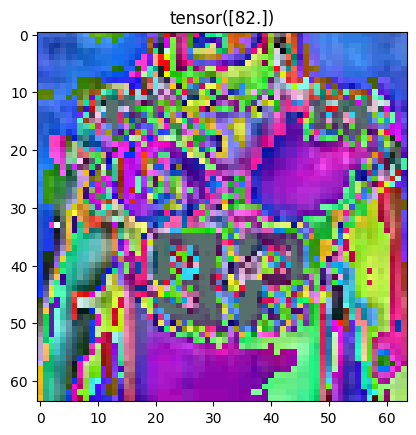

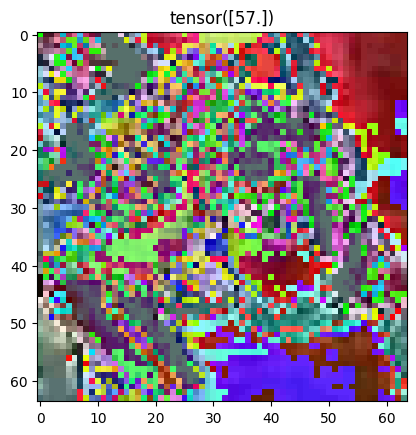

In [242]:
for image, label in val_loader:
    print(image.shape, image.dtype)
    print(image.mean(), image.std())
    print(label.shape, label.dtype)
    
    
    image_0 = v2.ToPILImage()(image[0])
    plt.imshow(image[0].permute(1, 2, 0).numpy().astype(np.uint8))
    plt.title(label[0])
    plt.show()

    image_2 = v2.ToPILImage()(image[2])
    plt.imshow(image[2].permute(1, 2, 0).numpy().astype(np.uint8))
    plt.title(label[2])
    plt.show()

    break


### Training Loop

In [137]:
model_kwargs = {
    "kernel": 3,
    "num_filters": 64,
    "num_in_channels": 3,
    "num_classes": 100,
    "width": 64,
    "height": 64,
}

train_config = {
    "batch_size": 32,
    "num_epochs": 10,
    "learning_rate": 1e-3,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

model = OCRNet(**model_kwargs).to(train_config["device"])
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=train_config["learning_rate"])

losses = {
    "train": [],
    "val": [],
}
for epoch in tqdm(range(train_config["num_epochs"])):
     
    train_loss, train_cmat = epoch_step(model, train_loader, criterion, optimizer, train_config["device"], step_type = "train")
    val_loss, val_cmat = epoch_step(model, val_loader, criterion, optimizer, train_config["device"], step_type = "eval")

    # accuracy
    train_accuracy = train_cmat.diag().sum() / train_cmat.sum()
    val_accuracy = val_cmat.diag().sum() / val_cmat.sum()

    # class-wise F1 (cmat rows are true labels, columns are predicted labels)
    # => sum axis = 0 gives 
    train_precision = train_cmat.diag() / train_cmat.sum(axis=0) # TP / (TP + FP) 
    val_precision = val_cmat.diag() / val_cmat.sum(axis=0)

    train_recall = train_cmat.diag() / train_cmat.sum(axis=1) # TP / (TP + FN)
    val_recall = val_cmat.diag() / val_cmat.sum(axis=1)

    train_f1_class = 2 * train_precision * train_recall / (train_precision + train_recall)
    val_f1_class = 2 * val_precision * val_recall / (val_precision + val_recall)

    train_f1_macro = train_f1_class.mean()
    val_f1_macro = val_f1_class.mean() 
    
    break

  0%|          | 0/10 [00:00<?, ?it/s]


RuntimeError: Input type (unsigned char) and bias type (float) should be the same